# 10_SHAP_Interpretability
This notebook explains the predictions of the XGBoost model using SHAP (SHapley Additive Explanations).

Objectives:

- Understand feature importance
- Explain model decisions
- Identify fault-driving features
- Improve model transparency

# SHAP-Based Model Interpretability Setup

In [1]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



# Imports

In [2]:
import pandas as pd
import numpy as np

import shap

from xgboost import XGBClassifier

from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt

# Dataset Loaded for SHAP Analysis

In [3]:
df = pd.read_csv(
    "phase1_full_dataset.csv"
)

print(df.shape)

(6153, 25)


# Feature Matrix and Target Variable Preparation

In [5]:
X = df.drop(
    columns=[
        "Label",
        "Source_File",
        "RPM"
    ],
    errors="ignore"
)

y = df["Label"]

groups = df["Source_File"]

# Group-Based Train-Test Split for SHAP Evaluation

In [6]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# XGBoost Model Training for Explainability Analysis

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# SHAP TreeExplainer Initialization

In [8]:
explainer = shap.TreeExplainer(
    xgb_model
)

# Calculate SHAP Values

In [11]:
shap_values = explainer.shap_values(
    X_test
)

# Summary Plot for Multi-Class Fault Classification

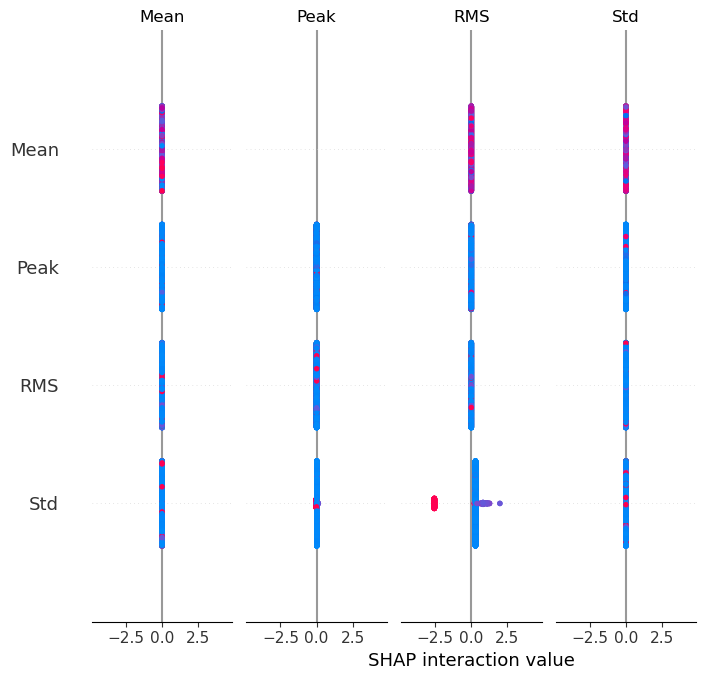

In [10]:
shap.summary_plot(
    shap_values,
    X_test
)

# Global Feature Importance Based on SHAP Values

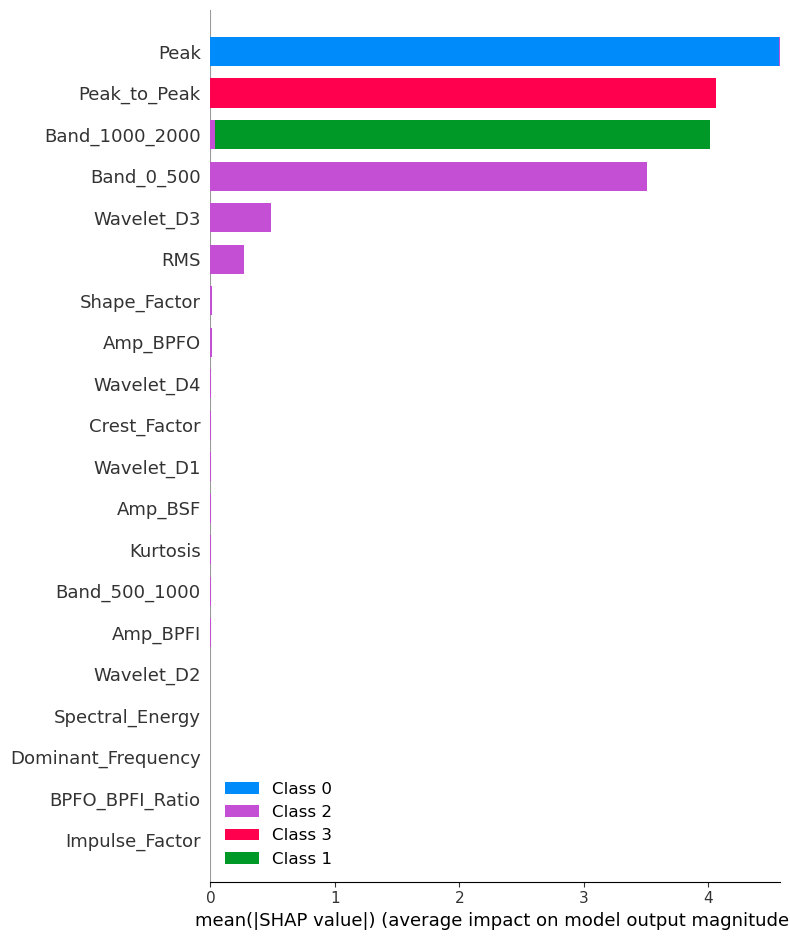

In [12]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# SHAP Value Tensor Dimensions

In [14]:
print(type(shap_values))

print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(2364, 23, 4)


In [15]:
mean_shap = np.abs(
    shap_values
).mean(axis=(0,2))

# Ranked SHAP Feature Importance Scores

In [16]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Importance": mean_shap
})

importance_df = importance_df.sort_values(
    by="SHAP_Importance",
    ascending=False
)

importance_df.head(10)

,Feature,SHAP_Importance
3,Peak,1.144649
4,Peak_to_Peak,1.015869
18,Band_1000_2000,1.004849
16,Band_0_500,0.877310
21,Wavelet_D3,0.121450
1,RMS,0.067154
8,Shape_Factor,0.003161
12,Amp_BPFO,0.002251
22,Wavelet_D4,0.000943
7,Crest_Factor,0.000818


# Top Ten Features Identified by SHAP Analysis

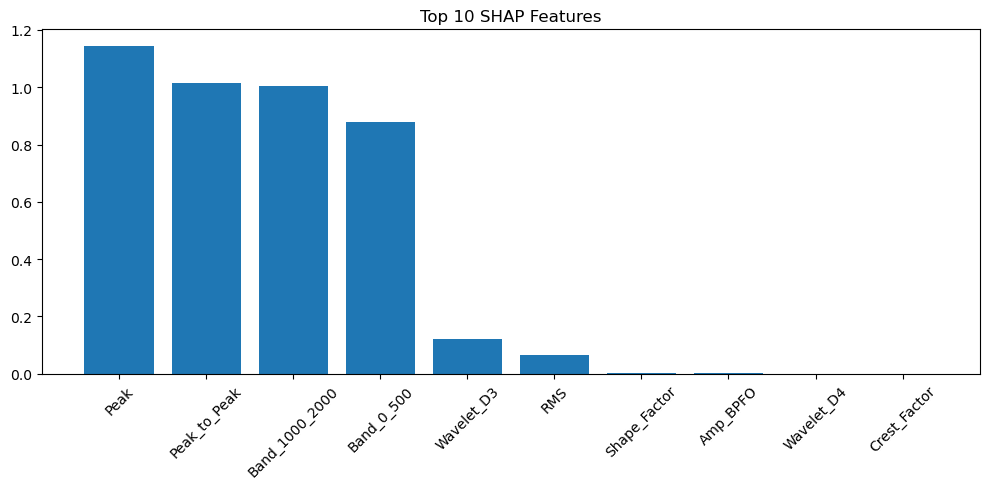

In [18]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["Feature"],
    top10["SHAP_Importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 SHAP Features"
)

plt.tight_layout()

plt.show()

# Save Results

In [21]:
importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("SHAP results saved.")

SHAP results saved.
